# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique
used to transform a dataset with many features into a smaller number of
new features called Principal Components.

PCA tries to preserve as much information (variance) as possible while
reducing the number of dimensions.

PCA is mainly used for:

- Dimensionality Reduction
- Data Visualization
- Removing Redundancy
- Noise Reduction
- Improving Computational Efficiency

## Important Concept

PCA does NOT simply select existing features.

Instead, PCA creates new features called:

**Principal Components**

For example:

Original Features:

X1, X2, X3, X4, X5

After PCA:

PC1, PC2

PC1 and PC2 are new combinations of the original features.

## PCA Intuition

Imagine a dataset with two highly correlated features:

Height in cm
Height in inches

Both contain almost the same information.

PCA can combine this information into a smaller number of principal
components.

The goal is to find directions where the data has the greatest variance.

The first principal component captures the maximum variance.

The second principal component captures the maximum remaining variance
while being perpendicular to the first component.

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

X = pd.DataFrame({
    "Feature_1": np.random.normal(50, 10, 200),
    "Feature_2": np.random.normal(100, 20, 200),
    "Feature_3": np.random.normal(30, 5, 200),
    "Feature_4": np.random.normal(70, 15, 200)
})

X.head()

,Feature_1,Feature_2,Feature_3,Feature_4
0,54.967142,107.155747,22.027862,81.354829
1,48.617357,111.215691,27.003125,56.167520
2,56.476885,121.661025,30.026218,83.044089
3,65.230299,121.076041,30.234903,90.334568
4,47.658466,72.446613,27.749673,76.201524


In [2]:
X.corr()

,Feature_1,Feature_2,Feature_3,Feature_4
Feature_1,1.000000,0.095147,-0.134197,0.065398
Feature_2,0.095147,1.000000,-0.032626,-0.101396
Feature_3,-0.134197,-0.032626,1.000000,0.105959
Feature_4,0.065398,-0.101396,0.105959,1.000000


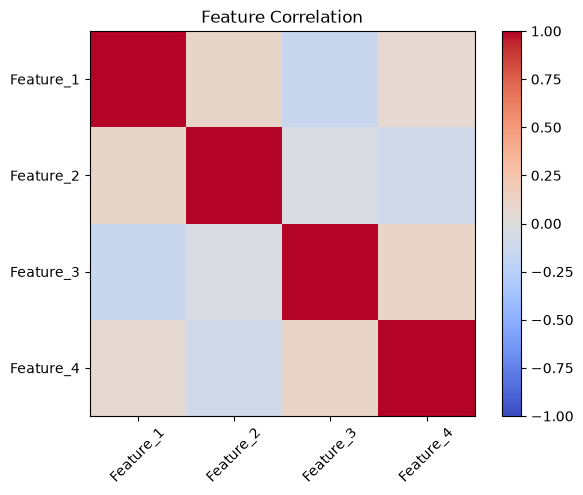

In [3]:
import matplotlib.pyplot as plt

correlation = X.corr()

plt.figure(figsize=(7, 5))

plt.imshow(
    correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar()

plt.xticks(
    range(len(X.columns)),
    X.columns,
    rotation=45
)

plt.yticks(
    range(len(X.columns)),
    X.columns
)

plt.title("Feature Correlation")

plt.show()

## Why Scaling is Important Before PCA?

PCA is sensitive to the scale of features.

Suppose:

Age → 18 to 60

Income → 20,000 to 100,000

Income has much larger numerical values.

Without scaling, features with larger scales can dominate the PCA
calculation.

Therefore, standardization is usually performed before PCA.

Common approach:

StandardScaler → PCA

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.57876651,  0.27619096, -1.52162464,  0.7355021 ],
       [-0.10498128,  0.48237717, -0.51809595, -0.91554733],
       [ 0.74133645,  1.01284857,  0.09167303,  0.84623449],
       [ 1.68390811,  0.98313988,  0.13376544,  1.32413156],
       [-0.20823509, -1.48652939, -0.36751455,  0.39769855]])

## Applying PCA

Scikit-learn provides the `PCA` class.

We can specify the number of components we want.

For example:

`n_components=2`

means that the original features will be transformed into two principal
components.

In [5]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(200, 2)

In [6]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,-1.034233,0.994990
1,-0.860007,-0.775588
2,-0.487062,0.953974
3,-0.719089,1.925192
4,0.792607,0.402515


## Explained Variance

Explained variance tells us how much information (variance) each
principal component captures from the original dataset.

For example:

PC1 → 50%

PC2 → 30%

PC3 → 15%

PC4 → 5%

PC1 captures the largest amount of variance.

The components are ordered from highest explained variance to lowest.

In [7]:
pca.explained_variance_ratio_

array([0.30220215, 0.26689441])

In [8]:
explained_variance = pd.DataFrame({
    "Component": ["PC1", "PC2"],
    "Explained_Variance": pca.explained_variance_ratio_
})

explained_variance

,Component,Explained_Variance
0,PC1,0.302202
1,PC2,0.266894


## Cumulative Explained Variance

Cumulative explained variance tells us how much total variance is
preserved when multiple components are combined.

For example:

PC1 → 50%

PC1 + PC2 → 80%

PC1 + PC2 + PC3 → 95%

This helps us decide how many principal components should be retained.

In [9]:
pca_full = PCA()

pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

cumulative_variance

array([0.30220215, 0.56909656, 0.81044496, 1.        ])

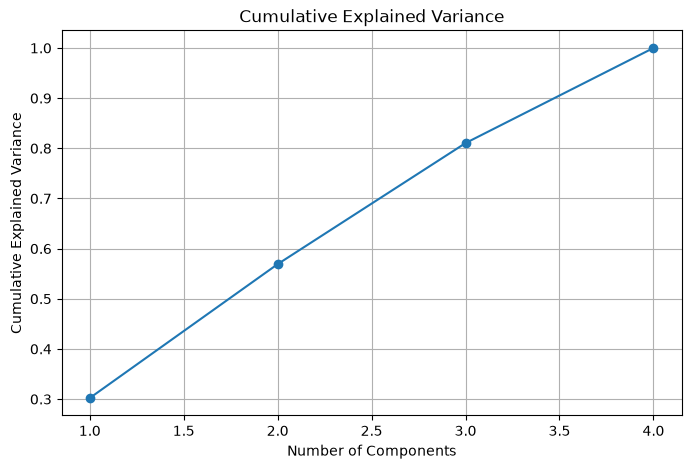

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.grid()

plt.show()

## Choosing the Number of Components

There are different ways to decide how many components to keep.

### 1. Explained Variance

Keep enough components to preserve a desired percentage of variance.

Common choices:

90%
95%
99%

### 2. Scree Plot

Look for an "elbow" where adding additional components provides
relatively little additional variance.

### 3. Model Performance

Choose the number of components that provides a good balance between
dimensionality reduction and model performance.

In [11]:
pca_95 = PCA(
    n_components=0.95
)

X_pca_95 = pca_95.fit_transform(X_scaled)

print("Original Features:", X.shape[1])
print("Selected Components:", X_pca_95.shape[1])

Original Features: 4
Selected Components: 4


## PCA Visualization

PCA can reduce high-dimensional data to two dimensions.

This allows us to visualize complex datasets in a 2D plot.

Here:

X-axis → PC1

Y-axis → PC2

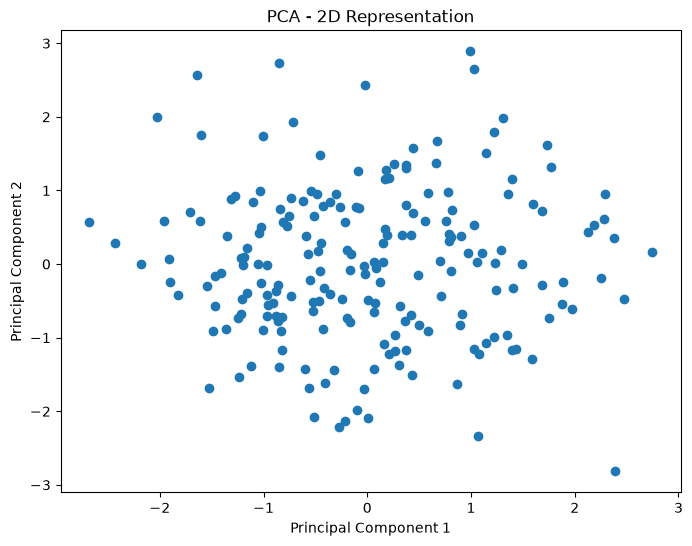

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - 2D Representation")

plt.show()

## PCA Components

Each principal component is a linear combination of the original
features.

For example:

PC1 = 0.50(X1) + 0.45(X2) - 0.20(X3) + ...

The coefficients are called loadings.

They indicate how strongly each original feature contributes to a
principal component.

In [13]:
pca.components_

array([[-0.48806032, -0.50601567,  0.59239266,  0.39346689],
       [ 0.65542298, -0.14686137, -0.07499914,  0.73703974]])

In [14]:
loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=["PC1", "PC2"]
)

loadings

,Feature_1,Feature_2,Feature_3,Feature_4
PC1,-0.488060,-0.506016,0.592393,0.393467
PC2,0.655423,-0.146861,-0.074999,0.737040


## PCA vs Feature Selection

### Feature Selection

Selects existing features.

Example:

Age
Income
Experience

→ Select:

Age
Income

### PCA

Creates new features from existing features.

Example:

Age
Income
Experience

→

PC1
PC2

Therefore:

Feature Selection → Keeps original features

PCA → Creates new features

## Limitations of PCA

- Principal components are difficult to interpret.
- PCA is sensitive to feature scaling.
- PCA is sensitive to outliers.
- Some information is lost when components are removed.
- Components are combinations of original features.
- PCA does not use the target variable.